In [10]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from IPython.display import display

# Fase 1 — Análise Exploratória

## 1.1 Carregamento do dataset 

O MNIST é obtido via `fetch_openml`, que baixa a versão 1 da base e a mantém em cache local. A semente global é fixada em 42 para garantir reprodutibilidade em todas as etapas
que envolvem aleatoriedade.

In [11]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Baixando o dataset MNIST...")
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
print("Finalizou o processo de baixar o dataset MNIST!")

X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.uint8)

Baixando o dataset MNIST...


KeyboardInterrupt: 

## 1.2 Dimensionalidade e domínio dos dados

Inspeção das dimensões das matrizes, dos tipos de dados e da faixa de intensidade dos pixels. O objetivo é confirmar a estrutura esperada antes de qualquer transformação e
identificar a escala das features, que determina a necessidade de normalização na Fase 2.

In [ ]:
print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print(f"Tipo de X: {X.dtype} | Tipo de y: {y.dtype}")
print(f"Intensidade mínima: {X.min()} | máxima: {X.max()}")
print(f"Classes presentes: {np.unique(y)}")

Formato de X: (70000, 784)
Formato de y: (70000,)
Tipo de X: float32 | Tipo de y: uint8
Intensidade mínima: 0.0 | máxima: 255.0
Classes presentes: [0 1 2 3 4 5 6 7 8 9]


## 1.3 Contagem de amostras por classe

Frequência absoluta e relativa de cada dígito. Um desbalanceamento acentuado exigiria reamostragem ou ponderação de classes, além de tornar a acurácia global uma métrica
enganosa.

In [ ]:
contagem = pd.Series(y).value_counts().sort_index()
proporcao = (contagem / len(y) * 100).round(2)

resumo_classes = pd.DataFrame({"amostras": contagem, "percentual": proporcao})
resumo_classes.index.name = "digito"
display(resumo_classes)


,amostras,percentual
digito,,
0,6903,9.86
1,7877,11.25
2,6990,9.99
3,7141,10.20
4,6824,9.75
5,6313,9.02
6,6876,9.82
7,7293,10.42
8,6825,9.75


## 1.4 Medidas de dispersão do balanceamento

Quantificação do que o gráfico sugere. O desvio-padrão dos percentuais e a razão entre  classe mais e a menos frequente substituem a leitura visual por um critério objetivo de
balanceamento.

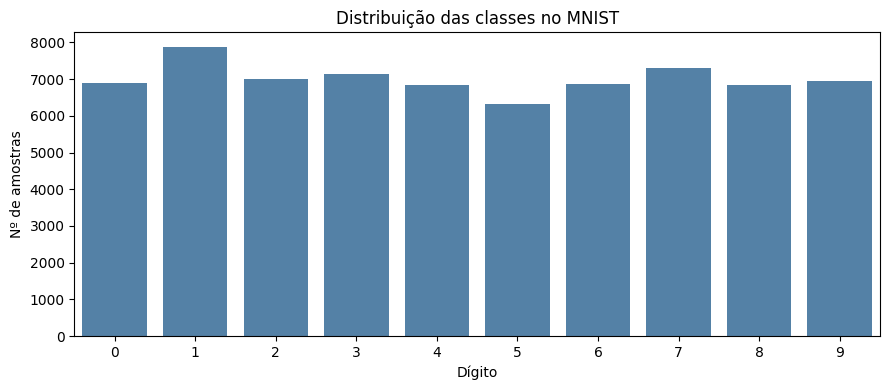

Desvio-padrão dos percentuais: 0.57 p.p.
Razão entre a classe mais e a menos frequente: 1.25:1
Classe mais frequente: 1 | menos frequente: 5


In [ ]:

plt.figure(figsize=(9, 4))
sns.barplot(x=contagem.index, y=contagem.values, color="steelblue")
plt.title("Distribuição das classes no MNIST")
plt.xlabel("Dígito")
plt.ylabel("Nº de amostras")
plt.tight_layout()
plt.show()

desvio_padrao = proporcao.std()
razao = contagem.max() / contagem.min()
print(f"Desvio-padrão dos percentuais: {desvio_padrao:.2f} p.p.")
print(f"Razão entre a classe mais e a menos frequente: {razao:.2f}:1")
print(f"Classe mais frequente: {contagem.idxmax()} | menos frequente: {contagem.idxmin()}")

## 1.5 Variabilidade de escrita dentro de cada classe

Cinco exemplares sorteados de cada dígito, com semente fixa para garantir que a grade seja reprodutível. Exibir múltiplas amostras por classe, em vez de uma só, revela a dispersão
intraclasse: o mesmo dígito aparece com inclinações, espessuras de traço e proporções distintas. Essa variação intraclasse não carrega informação sobre o rótulo, e o classificador precisa se tornar invariante a ela — retendo apenas os traços que distinguem um dígito de outro.

A grade também antecipa a dificuldade do problema. Dígitos de classes diferentes podem ocupar regiões de pixel muito semelhantes, o que sugere quais pares tendem a concentrar
os erros na matriz de confusão da Fase 4.

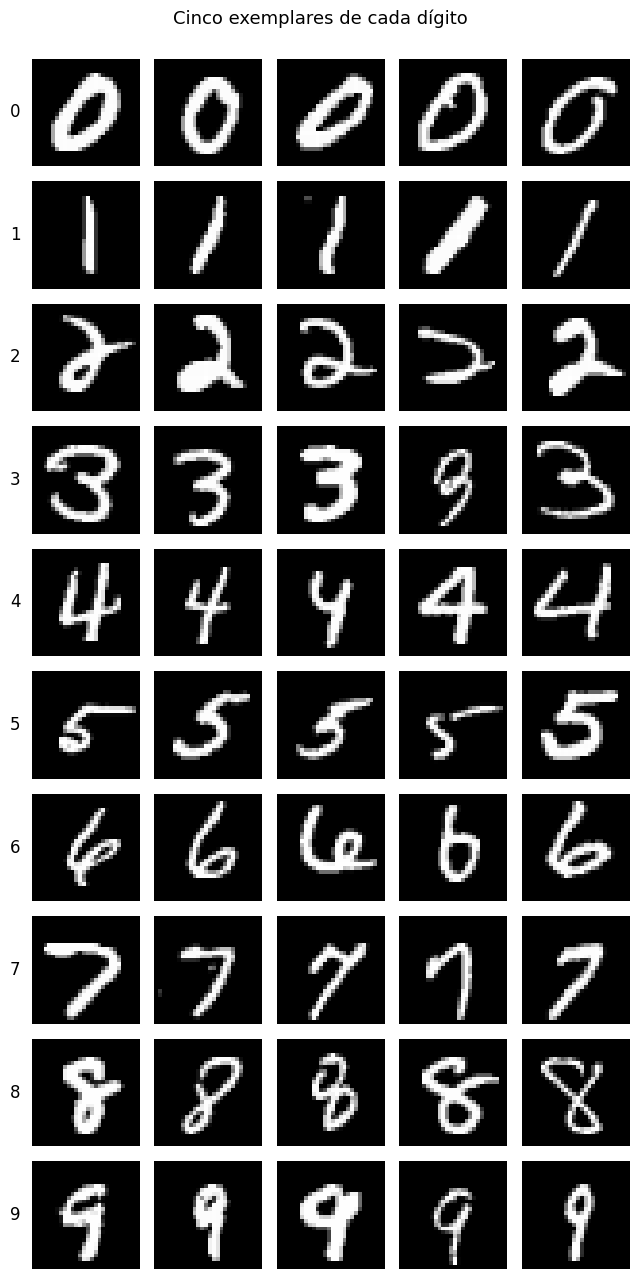

In [ ]:
N_AMOSTRAS = 5
sorteador = np.random.RandomState(RANDOM_STATE)

fig, eixos = plt.subplots(10, N_AMOSTRAS, figsize=(N_AMOSTRAS * 1.3, 13))

for digito in range(10):
    indices = sorteador.choice(np.where(y == digito)[0], N_AMOSTRAS, replace=False)
    for coluna, indice in enumerate(indices):
        eixo = eixos[digito, coluna]
        eixo.imshow(X[indice].reshape(28, 28), cmap="gray")
        eixo.set_xticks([])
        eixo.set_yticks([])
        for borda in eixo.spines.values():
            borda.set_visible(False)
        if coluna == 0:
            eixo.set_ylabel(str(digito), rotation=0, labelpad=12,
                            fontsize=12, va="center")

fig.suptitle("Cinco exemplares de cada dígito", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## 1.6 Interpretação da estrutura dos dados



**Representação dos pixels.** Cada imagem do MNIST é uma matriz 28 x 28 em escala de cinza, totalizando 784 pixels. Cada posição armazena a intensidade luminosa daquele ponto
como um valor de 0 a 255, confirmado pela inspeção de `X.min()` e `X.max()`. O 0 representa o preto absoluto (fundo do papel digitalizado) e o 255 o branco absoluto (região
de traço mais intenso). Os valores intermediários correspondem ao antialiasing das bordas, resultado do processo de normalização e reamostragem aplicado quando a base original do
NIST foi convertida para 28 x 28.

Podemos observar que a convenção é inversa à da escrita manual comum, o traço é claro sobre fundo escuro, não o contrário. Essa observação é o que justifica a inversão de cores no pipeline de pré-processamento das imagens próprias, na Fase 5.

**Vetorização em 784 features.** O `fetch_openml` entrega os dados já achatados, no formato (70000, 784). O achatamento percorre a matriz linha a linha (row-major) e
concatena os resultados, de modo que o pixel na posição (i, j) da imagem ocupa o índice i * 28 + j do vetor. É por isso que `X[k].reshape(28, 28)` reconstrói a imagem original. A operação apenas desfaz o achatamento.

Essa representação é o que permite tratar cada imagem como uma observação tabular convencional, com 784 variáveis independentes, formato exigido pelos estimadores do
scikit-learn. O custo é a perda da noção de vizinhança espacial. Para o KNN ou a Random Forest, as colunas 27 e 28 são apenas duas variáveis quaisquer, embora correspondam a
pixels verticalmente adjacentes na imagem. Redes convolucionais eliminam essa limitação ao operar sobre a estrutura 2D preservada, mas a MLP da Fase 3 também recebe o vetor
achatado. A comparação entre os três modelos ocorre, portanto, sobre a mesma representação de entrada.

**Rótulos.** O vetor `y` traz 70.000 rótulos, um por imagem, convertidos de string para `uint8`. As dez classes de 0 a 9 estão todas presentes, o que confirma tratar-se de um
problema de classificação multiclasse de saída única, onde cada imagem pertence a exatamente uma categoria.

**Distribuição das classes.** A base é aproximadamente balanceada. O dígito 1 é o mais frequente (7.877 amostras, 11,25%) e o 5 o menos frequente (6.313 amostras, 9,02%), uma razão de 1,25:1 entre os extremos. Todas as classes ficam próximas dos 10% esperados em uma distribuição uniforme.

Essa leve assimetria não configura desbalanceamento problemático e não exige reamostragem ou ponderação de classes. A consequência prática é dupla: a acurácia global permanece uma
métrica confiável, pois nenhuma classe é rara o suficiente para ser ignorada pelo modelo sem penalidade perceptível; e a média ponderada das métricas por classe ficará próxima da
média macro. Ainda assim, a análise por classe na Fase 4 permanece necessária,  pois o balanceamento da base não garante desempenho homogêneo entre dígitos, já que a dificuldade
de discriminação varia conforme a semelhança morfológica entre eles.

# Fase 2 — Pré-processamento

## 2.1 Divisão em treino, validação e teste

Separação em 70% para treino, 10% para validação e 20% para teste, com estratificação por classe. A tabela de proporções comprova que a distribuição original foi preservada nos três subconjuntos.

In [ ]:
from sklearn.model_selection import train_test_split

# 20% para teste
X_temp, X_teste, y_temp, y_teste = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# dos 80% restantes, 12,5% viram validação => 10% do total
X_treino, X_val, y_treino, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=RANDOM_STATE
)

for nome, conjunto in [("Treino", y_treino), ("Validação", y_val), ("Teste", y_teste)]:
    print(f"{nome}: {len(conjunto)} amostras ({len(conjunto)/len(y)*100:.0f}%)")

# comprova que a estratificação preservou as proporções
proporcoes = pd.DataFrame({
    "treino": pd.Series(y_treino).value_counts(normalize=True).sort_index(),
    "validacao": pd.Series(y_val).value_counts(normalize=True).sort_index(),
    "teste": pd.Series(y_teste).value_counts(normalize=True).sort_index(),
}).round(4)
display(proporcoes)

Treino: 49000 amostras (70%)
Validação: 7000 amostras (10%)
Teste: 14000 amostras (20%)


,treino,validacao,teste
0,0.0986,0.0986,0.0986
1,0.1125,0.1126,0.1125
2,0.0999,0.0999,0.0999
3,0.1020,0.1020,0.1020
4,0.0975,0.0974,0.0975
5,0.0902,0.0901,0.0902
6,0.0982,0.0983,0.0982
7,0.1042,0.1041,0.1042
8,0.0975,0.0976,0.0975
9,0.0994,0.0994,0.0994


## 2.2 Normalização da escala dos pixels

Conversão da faixa original de 0 a 255 para o intervalo [0, 1], aplicada após a separação dos conjuntos, para preservar a independência do conjunto de teste.


In [ ]:
X_treino = X_treino / 255.0
X_val = X_val / 255.0
X_teste = X_teste / 255.0

print(f"Faixa após normalização — treino: [{X_treino.min():.1f}, {X_treino.max():.1f}]")


Faixa após normalização — treino: [0.0, 0.0]


## 2.3 Justificativa técnica das decisões de pré-processamento

### Por que normalizar

**Divisão estratificada.** Com `stratify=y`, a proporção de cada dígito é preservada nos três conjuntos. Sem isso, a amostragem aleatória poderia sub-representar uma classe no teste e produzir uma acurácia otimista ou pessimista por artefato de amostragem. O conjunto de validação existe para o ajuste de hiperparâmetros, mantendo o teste como conjunto verdadeiramente independente, tocado uma única vez na Fase 4.

**Escala dos pixels.** Dividir por 255.0 leva todas as 784 features para [0, 1]:

- *Modelos baseados em distância (KNN):* a distância euclidiana soma diferenças ao quadrado entre pixels. Em escala 0–255, cada pixel pode contribuir com até 65.025 para essa soma, o que produz valores de magnitude elevada e sensibilidade numérica desnecessária. Em [0, 1] a contribuição máxima por pixel cai para 1.
- *Redes neurais (MLP):* entradas grandes produzem ativações grandes, que empurram sigmoide e tanh para as regiões de saturação onde o gradiente tende a zero. Com entradas em [0, 1] e inicialização adequada dos pesos, a superfície de erro fica mais bem condicionada e o gradiente descendente converge em menos épocas.
- *Modelos baseados em árvores (Random Forest):* são invariantes a transformações monotônicas, pois os splits comparam limiares dentro de cada feature isoladamente. Normalizar não prejudica e mantém o pipeline uniforme entre os três modelos.

**Vazamento de dados.** A normalização é aplicada após o split. Com divisão por constante o efeito numérico é o mesmo, mas a ordem correta é o que impede que estatísticas do teste influenciem o treino caso a estratégia mude para um scaler ajustado aos dados.


# Fase 3 - Treinamento dos modelos

## Treina o KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

resultados = {}   # dicionário compartilhado entre as três branches de modelo

# subamostra estratificada apenas para a busca de hiperparâmetros
idx_busca, _ = train_test_split(
    np.arange(len(y_treino)), train_size=10_000,
    stratify=y_treino, random_state=RANDOM_STATE
)
X_busca, y_busca = X_treino[idx_busca], y_treino[idx_busca]

inicio = time.time()
knn_base = KNeighborsClassifier(n_neighbors=5, weights="uniform", n_jobs=-1)
knn_base.fit(X_busca, y_busca)
acuracia_base = accuracy_score(y_val, knn_base.predict(X_val))
print(f"KNN base (k=5, uniform): {acuracia_base:.4f} em {time.time()-inicio:.1f}s")